# Text Classification using IndoBERT

## Case Study: Multiclass Sports News Classification

Proyek ini membangun model klasifikasi berita olahraga menggunakan pretrained language model (**IndoBERT**). Dataset dikumpulkan melalui web scraping dari dua media berita digital di Indonesia, kemudian melalui tahap preprocessing, fine-tuning, dan evaluasi.

Dua pendekatan klasifikasi yang digunakan:

1. **One-Stage Classification** — mengklasifikasikan artikel langsung ke dalam lima kategori.
2. **Two-Stage Classification** — Stage 1 membedakan Sepak Bola dan Non Sepak Bola, kemudian Stage 2 mengklasifikasikan artikel Sepak Bola ke dalam empat liga.

Kedua pendekatan dibandingkan menggunakan **Accuracy, Precision, Recall, dan F1-Score**.


# 1. Import Libraries

Pada bagian ini dilakukan import seluruh library yang dibutuhkan selama proses **web scraping**, **text preprocessing**, visualisasi data, pelatihan model **Large Language Model (LLM)**, serta evaluasi hasil klasifikasi.

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

# System
import os
import re
import gc
import random
import warnings
import time


warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Web Scraping
import requests
from bs4 import BeautifulSoup
from tqdm.auto import tqdm
import xml.etree.ElementTree as ET

# NLP
import sentencepiece

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Deep Learning
import torch

# HuggingFace
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# 2. Configuration

Bagian ini berisi seluruh konfigurasi yang digunakan selama pengerjaan proyek, seperti **random seed**, nama model **LLM**, lokasi penyimpanan dataset, direktori output, serta konfigurasi label yang digunakan dalam proses klasifikasi.

In [2]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# ==========================================================
# DEVICE CONFIGURATION
# ==========================================================

DEVICE = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# ==========================================================
# MODEL CONFIGURATION
# ==========================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

# ==========================================================
# DATA CONFIGURATION
# ==========================================================

DATA_DIR = "./data/question1"

RAW_DATA_PATH = os.path.join(DATA_DIR, "berita_raw.csv")
CLEAN_DATA_PATH = os.path.join(DATA_DIR, "berita_clean.csv")
FINAL_DATA_PATH = os.path.join(DATA_DIR, "berita_final.csv")

# ==========================================================
# SCRAPING CONFIGURATION
# ==========================================================

TARGET_PER_CLASS = 250

MEDIA = [
    "Detik",
    "Bola.net"
]

# URL akan diisi pada Section Web Scraping
NEWS_SOURCES = {}

HEADERS = {
    "User-Agent":
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/138.0 Safari/537.36"
}

REQUEST_TIMEOUT = 30

# ==========================================================
# LABEL CONFIGURATION
# ==========================================================

LABEL_MAPPING = {
    "Liga Inggris": 0,
    "Liga Indonesia": 1,
    "Liga Spanyol": 2,
    "Liga Italia": 3,
    "Non Sepak Bola": 4
}

ID2LABEL = {v: k for k, v in LABEL_MAPPING.items()}

# ==========================================================
# TRAINING CONFIGURATION
# ==========================================================

MAX_LENGTH = 256

TRAIN_SIZE = 0.8
VALID_SIZE = 0.1
TEST_SIZE = 0.1

BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 3

# Hyperparameter Tuning
LEARNING_RATE_LIST = [2e-5, 5e-5]
BATCH_SIZE_LIST = [16, 32]

# ==========================================================
# OUTPUT CONFIGURATION
# ==========================================================

MODEL_DIR = "./models/question1"

RAW_URL_PATH = os.path.join(DATA_DIR, "article_urls.csv")

MODEL_1_PATH = os.path.join(MODEL_DIR, "model_1stage")
MODEL_2_STAGE1_PATH = os.path.join(MODEL_DIR, "model_2stage", "stage1")
MODEL_2_STAGE2_PATH = os.path.join(MODEL_DIR, "model_2stage", "stage2")

OUTPUT_DIR = "./output/question1"

FIGURE_PATH = os.path.join(OUTPUT_DIR, "figures")
RESULT_PATH = os.path.join(OUTPUT_DIR, "results")
REPORT_PATH = os.path.join(OUTPUT_DIR, "reports")

# ==========================================================
# CONFIGURATION SUMMARY
# ==========================================================

print("=" * 60)
print("CONFIGURATION LOADED")
print("=" * 60)

print(f"Device              : {DEVICE}")
print(f"Model               : {MODEL_NAME}")
print(f"Random State        : {RANDOM_STATE}")
print(f"Target per Class    : {TARGET_PER_CLASS}")
print(f"Total Classes       : {len(LABEL_MAPPING)}")
print(f"Training Split      : {TRAIN_SIZE:.0%}")
print(f"Validation Split    : {VALID_SIZE:.0%}")
print(f"Testing Split       : {TEST_SIZE:.0%}")

print("=" * 60)

CONFIGURATION LOADED
Device              : mps
Model               : indobenchmark/indobert-base-p1
Random State        : 42
Target per Class    : 250
Total Classes       : 5
Training Split      : 80%
Validation Split    : 10%
Testing Split       : 10%


In [3]:
# ==========================================================
# CREATE PROJECT FOLDERS
# ==========================================================

folders = [
    # Data
    DATA_DIR,

    # Models
    MODEL_DIR,
    MODEL_1_PATH,
    MODEL_2_STAGE1_PATH,
    MODEL_2_STAGE2_PATH,

    # Output
    OUTPUT_DIR,
    FIGURE_PATH,
    RESULT_PATH,
    REPORT_PATH,
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("=" * 60)
print("PROJECT FOLDERS CREATED SUCCESSFULLY")
print("=" * 60)

for folder in folders:
    print(f"✓ {folder}")

PROJECT FOLDERS CREATED SUCCESSFULLY
✓ ./data/question1
✓ ./models/question1
✓ ./models/question1/model_1stage
✓ ./models/question1/model_2stage/stage1
✓ ./models/question1/model_2stage/stage2
✓ ./output/question1
✓ ./output/question1/figures
✓ ./output/question1/results
✓ ./output/question1/reports


# 3. Environment

Pada bagian ini dilakukan pengecekan terhadap environment yang digunakan, termasuk versi **PyTorch**, ketersediaan **GPU Apple Metal Performance Shaders (MPS)**, serta device yang akan digunakan selama proses pelatihan model.

In [4]:
print("="*50)
print("DEVICE INFORMATION")
print("="*50)

print("Torch Version :", torch.__version__)
print("CUDA :", torch.cuda.is_available())
print("MPS :", torch.backends.mps.is_available())
print("Device :", DEVICE)

DEVICE INFORMATION
Torch Version : 2.12.1
CUDA : False
MPS : True
Device : mps


# 4. Data Collection

### Tujuan

Tahap ini bertujuan mengumpulkan dataset berita olahraga dari dua media berita digital di Indonesia, yaitu Detik Sport dan Bola.net, sebagai sumber data utama untuk proses klasifikasi berita berdasarkan kategori kompetisi sepak bola.

### Metode

Pengumpulan data dilakukan dalam dua tahap.

Tahap pertama adalah mengumpulkan seluruh URL artikel berdasarkan kategori berita. Metode pengambilan URL disesuaikan dengan struktur masing-masing media berita.

- Detik Sport menggunakan sitemap XML, sehingga daftar URL artikel dapat diperoleh secara langsung dari sitemap pada setiap kategori.
- Bola.net menggunakan halaman kategori beserta pagination, sehingga scraper dapat menelusuri setiap halaman hingga jumlah artikel yang diinginkan tercapai.

Tahap kedua adalah mengambil informasi lengkap dari setiap URL artikel, meliputi:

- Judul berita
- Isi berita
- Tanggal publikasi
- Nama media
- URL
- Label kategori

Seluruh URL disimpan terlebih dahulu sebelum proses pengambilan isi artikel dilakukan. Pendekatan dua tahap ini membuat proses scraping lebih efisien, mudah direproduksi, serta memungkinkan proses pengumpulan data dilanjutkan apabila terjadi gangguan atau proses scraping terhenti di tengah jalan.

In [5]:
# ==========================================================
# HELPER FUNCTION
# ==========================================================

def get_html(url):

    response = requests.get(
        url,
        headers=HEADERS,
        timeout=REQUEST_TIMEOUT
    )

    response.raise_for_status()

    return response.text

In [6]:
def get_detik_sitemap_urls(sitemap_url):

    xml = get_html(sitemap_url)

    soup = BeautifulSoup(xml, "xml")

    urls = []

    for loc in soup.find_all("loc"):
        urls.append(loc.text.strip())

    return urls

In [7]:
# ==========================================================
# BOLA.NET HTML PARSER
# ==========================================================

def get_bolanet_category_urls(base_url,
                              max_pages=3):

    urls = []

    for page in range(1, max_pages+1):

        if page == 1:
            page_url = base_url
        else:
            page_url = base_url + f"index{page}.html"

        try:

            soup = BeautifulSoup(
                get_html(page_url),
                "html.parser"
            )

            box = soup.find("div", class_="box-article")

            if box is None:
                break

            items = box.find_all("div", class_="item")

            before = len(urls)

            for item in items:

                a = item.find("a", href=True)

                if a:

                    href = a["href"]

                    if href.startswith("https://www.bola.net"):

                        urls.append(href)

            urls = list(dict.fromkeys(urls))

            print(
                f"Page {page:>2} | +{len(urls)-before} | Total {len(urls)}"
            )

            time.sleep(1)

        except Exception as e:

            print(page, e)
            break

    return urls

## 4.1 Konfigurasi Sitemap Detik

In [8]:
# ==========================================================
# DETIK SEPAK BOLA
# ==========================================================

DETIK_SITEMAPS = {

    "Liga Inggris":
    "https://sport.detik.com/sepakbola/liga-inggris/sitemap_web.xml",

    "Liga Indonesia":
    "https://sport.detik.com/sepakbola/liga-indonesia/sitemap_web.xml",

    "Liga Spanyol":
    "https://sport.detik.com/sepakbola/liga-spanyol/sitemap_web.xml",

    "Liga Italia":
    "https://sport.detik.com/sepakbola/liga-italia/sitemap_web.xml"

}

# ==========================================================
# DETIK NON SEPAK BOLA
# ==========================================================

NON_SEPAK_BOLA_SITEMAPS = {

    "Sport":
    "https://sport.detik.com/sport/sitemap_web.xml",

    "MotoGP":
    "https://oto.detik.com/motogp/sitemap_web.xml",

    "F1":
    "https://oto.detik.com/f1/sitemap_web.xml",

    "Raket":
    "https://sport.detik.com/raket/sitemap_web.xml",

    "Basket":
    "https://sport.detik.com/basket/sitemap_web.xml"

}

In [9]:
# ==========================================================
# CHECK SITEMAP
# ==========================================================

print("="*60)
print("SEPAK BOLA")
print("="*60)

for category, sitemap in DETIK_SITEMAPS.items():

    urls = get_detik_sitemap_urls(sitemap)

    print(f"{category:<20} : {len(urls)} URL")


print()

print("="*60)
print("NON SEPAK BOLA")
print("="*60)

for category, sitemap in NON_SEPAK_BOLA_SITEMAPS.items():

    urls = get_detik_sitemap_urls(sitemap)

    print(f"{category:<20} : {len(urls)} URL")

SEPAK BOLA
Liga Inggris         : 100 URL
Liga Indonesia       : 100 URL
Liga Spanyol         : 100 URL
Liga Italia          : 100 URL

NON SEPAK BOLA
Sport                : 100 URL
MotoGP               : 56 URL
F1                   : 56 URL
Raket                : 100 URL
Basket               : 100 URL


In [10]:
# ==========================================================
# COLLECT DETIK URL
# ==========================================================

detik_dataset = []

# ==========================================================
# SEPAK BOLA
# ==========================================================

for category, sitemap in DETIK_SITEMAPS.items():

    urls = get_detik_sitemap_urls(sitemap)

    temp = pd.DataFrame({

        "url": urls,
        "media": "Detik",
        "category": category,
        "label": LABEL_MAPPING[category]

    })

    detik_dataset.append(temp)

# ==========================================================
# NON SEPAK BOLA
# ==========================================================

for _, sitemap in NON_SEPAK_BOLA_SITEMAPS.items():

    urls = get_detik_sitemap_urls(sitemap)

    temp = pd.DataFrame({

        "url": urls,
        "media": "Detik",
        "category": "Non Sepak Bola",
        "label": LABEL_MAPPING["Non Sepak Bola"]

    })

    detik_dataset.append(temp)

In [11]:
# ==========================================================
# MERGE DETIK DATASET
# ==========================================================

df_detik = pd.concat(
    detik_dataset,
    ignore_index=True
)

df_detik.drop_duplicates(
    subset="url",
    inplace=True
)

df_detik.reset_index(
    drop=True,
    inplace=True
)

In [12]:
# ==========================================================
# DETIK SUMMARY
# ==========================================================

print("="*60)
print("DETIK DATASET")
print("="*60)

print(df_detik["category"].value_counts())

print()

print("="*60)
print("TOTAL URL :", len(df_detik))
print("="*60)

df_detik.head()

DETIK DATASET
category
Non Sepak Bola    245
Liga Inggris      100
Liga Indonesia    100
Liga Spanyol      100
Liga Italia       100
Name: count, dtype: int64

TOTAL URL : 645


,url,media,category,label
0,https://sport.detik.com/sepakbola/liga-inggris...,Detik,Liga Inggris,0
1,https://sport.detik.com/sepakbola/liga-inggris...,Detik,Liga Inggris,0
2,https://sport.detik.com/sepakbola/liga-inggris...,Detik,Liga Inggris,0
3,https://sport.detik.com/sepakbola/liga-inggris...,Detik,Liga Inggris,0
4,https://sport.detik.com/sepakbola/liga-inggris...,Detik,Liga Inggris,0


## 4.2 Pengambilan URL Artikel dari Bola.net

In [13]:
# ==========================================================
# BOLA.NET CATEGORIES
# ==========================================================

BOLANET_CATEGORIES = {

    "Liga Inggris":
    "https://www.bola.net/inggris/",

    "Liga Indonesia":
    "https://www.bola.net/indonesia/",

    "Liga Spanyol":
    "https://www.bola.net/spanyol/",

    "Liga Italia":
    "https://www.bola.net/italia/"
}

NON_SEPAK_BOLA_URLS = [

    "https://www.bola.net/basket/",
    "https://www.bola.net/bulutangkis/",
    "https://www.bola.net/tenis/",
    "https://www.bola.net/voli/",
    "https://www.bola.net/otomotif/"
]

In [14]:
# ==========================================================
# GET ARTICLE URL FROM BOLA.NET
# ==========================================================

def get_bolanet_category_urls(base_url,
                              max_pages=3):

    all_urls = []

    for page in range(1, max_pages + 1):

        if page == 1:
            page_url = base_url
        else:
            page_url = base_url.rstrip("/") + f"/index{page}.html"

        try:

            soup = BeautifulSoup(
                get_html(page_url),
                "html.parser"
            )

            items = soup.find_all("div", class_="item")

            page_urls = []

            for item in items:

                a = item.find("a", href=True)

                if a:

                    href = a["href"]

                    if href.startswith("https://www.bola.net"):

                        page_urls.append(href)

            page_urls = list(dict.fromkeys(page_urls))

            if len(page_urls) == 0:

                print(f"Page {page:>2} -> kosong")
                break

            all_urls.extend(page_urls)

            all_urls = list(dict.fromkeys(all_urls))

            print(
                f"Page {page:>2} | +{len(page_urls):>2} | Total {len(all_urls)}"
            )

            time.sleep(1)

        except Exception as e:

            print(f"Page {page:>2} -> {e}")

            continue

    return all_urls

In [15]:
# ==========================================================
# COLLECT FOOTBALL URL
# ==========================================================

football_dataset = []

for category, url in BOLANET_CATEGORIES.items():

    print("="*60)
    print(category)

    urls = get_bolanet_category_urls(
        url,
        max_pages=3
    )

    temp = pd.DataFrame({

        "url": urls,
        "media": "Bola.net",
        "category": category,
        "label": LABEL_MAPPING[category]

    })

    football_dataset.append(temp)

football_df = pd.concat(
    football_dataset,
    ignore_index=True
)

Liga Inggris
Page  1 | +23 | Total 23
Page  2 | +22 | Total 43
Page  3 | +23 | Total 64
Liga Indonesia
Page  1 | +22 | Total 22
Page  2 | +22 | Total 43
Page  3 | +22 | Total 64
Liga Spanyol
Page  1 | +22 | Total 22
Page  2 | +23 | Total 43
Page  3 | +23 | Total 64
Liga Italia
Page  1 | +22 | Total 22
Page  2 | +23 | Total 43
Page  3 | +23 | Total 64


In [16]:
# ==========================================================
# COLLECT NON FOOTBALL URL
# ==========================================================

non_urls = []

for url in NON_SEPAK_BOLA_URLS:

    print("="*60)
    print(url)

    urls = get_bolanet_category_urls(
        url,
        max_pages=3
    )

    non_urls.extend(urls)

non_urls = list(dict.fromkeys(non_urls))

https://www.bola.net/basket/
Page  1 | +23 | Total 23
Page  2 | +23 | Total 44
Page  3 | +23 | Total 65
https://www.bola.net/bulutangkis/
Page  1 | +22 | Total 22
Page  2 | +22 | Total 43
Page  3 | +22 | Total 64
https://www.bola.net/tenis/
Page  1 | +23 | Total 23
Page  2 | +23 | Total 44
Page  3 | +23 | Total 65
https://www.bola.net/voli/
Page  1 | +23 | Total 23
Page  2 | +23 | Total 44
Page  3 | +23 | Total 65
https://www.bola.net/otomotif/
Page  1 | +22 | Total 22
Page  2 | +23 | Total 43
Page  3 | +23 | Total 64


In [17]:
nonfootball_df = pd.DataFrame({

    "url": non_urls,
    "media": "Bola.net",
    "category": "Non Sepak Bola",
    "label": LABEL_MAPPING["Non Sepak Bola"]

})

In [18]:
# ==========================================================
# MERGE BOLA.NET DATASET
# ==========================================================

df_bolanet = pd.concat(

    [
        football_df,
        nonfootball_df
    ],

    ignore_index=True

)

df_bolanet = df_bolanet.drop_duplicates(
    subset="url"
).reset_index(drop=True)

In [19]:
# ==========================================================
# BOLA.NET SUMMARY
# ==========================================================

print("="*60)
print("BOLA.NET DATASET")
print("="*60)

print(df_bolanet["category"].value_counts())

print()

print("="*60)
print("TOTAL URL :", len(df_bolanet))
print("="*60)

df_bolanet.head()

BOLA.NET DATASET
category
Non Sepak Bola    318
Liga Inggris       64
Liga Indonesia     63
Liga Spanyol       63
Liga Italia        63
Name: count, dtype: int64

TOTAL URL : 571


,url,media,category,label
0,https://www.bola.net/inggris/akankah-marcus-ra...,Bola.net,Liga Inggris,0
1,https://www.bola.net/inggris/manchester-united...,Bola.net,Liga Inggris,0
2,https://www.bola.net/inggris/resmi-manchester-...,Bola.net,Liga Inggris,0
3,https://www.bola.net/inggris/luis-suarez-bongk...,Bola.net,Liga Inggris,0
4,https://www.bola.net/inggris/update-kondisi-te...,Bola.net,Liga Inggris,0


In [20]:
# ==========================================================
# MERGE DETIK + BOLA.NET
# ==========================================================

article_urls = pd.concat(

    [
        df_detik,
        df_bolanet
    ],

    ignore_index=True

)

article_urls = article_urls.drop_duplicates(
    subset="url"
).reset_index(drop=True)

In [21]:
# ==========================================================
# FINAL URL DATASET
# ==========================================================

print("="*60)
print("FINAL DATASET")
print("="*60)

print(article_urls["media"].value_counts())

print()

print(article_urls["category"].value_counts())

print()

print("Total :", len(article_urls))

FINAL DATASET
media
Detik       645
Bola.net    571
Name: count, dtype: int64

category
Non Sepak Bola    563
Liga Inggris      164
Liga Indonesia    163
Liga Spanyol      163
Liga Italia       163
Name: count, dtype: int64

Total : 1216


# 5. Article Scraping


## 5.1 Detik Scraping Function

In [22]:
# ==========================================================
# DETIK ARTICLE SCRAPER
# ==========================================================

def scrape_detik_article(url):

    try:

        soup = BeautifulSoup(
            get_html(url),
            "html.parser"
        )

        paragraphs = soup.select("div.detail__body-text p")

        text = []

        for p in paragraphs:

            t = p.get_text(" ", strip=True)

            if len(t):

                text.append(t)

        article = " ".join(text)

        return article.strip()

    except Exception:

        return None

In [23]:
test_url = df_detik.iloc[0]["url"]

print(test_url)

https://sport.detik.com/sepakbola/liga-inggris/d-8553029/chelsea-sindir-keras-maresca-sebut-xabi-alonso-jago-taktik-dan-profesional


In [24]:
article = scrape_detik_article(test_url)

print(article[:1000])

Chelsea tampak 'menyindir' keras Enzo Maresca , yang resmi jadi manajer Manchester City. The Blues membandingkannya dengan Xabi Alonso . Maresca baru saja diumumkan jadi manajer City pada Senin (29/6). Pria Italia itu dikontrak 3 tahun. Sebelum diumumkan, Maresca sempat membuat pernyataan soal alasan meninggalkan Chelsea awal tahun ini. Ia mengaku memang ingin cabut ke City dan meminta maaf karena pergi sehingga bikin tim jeblok. SCROLL TO CONTINUE WITH CONTENT Chelsea, di saat bersamaan, juga membuat pernyataan balasan. Raksasa London itu menjelaskan kronologi kepergian Maresca. Dalam penutup pernyataannya, Chelsea tampak menyindir Enzo Maresca . Tak secara langsung, raksasa London Barat itu justru membandingkannya dengan Xabi Alonso . "Menatap musim depan, dalam diri Xabi Alonso, kami memiliki seorang manajer yang memiliki kecerdasan taktis luar biasa dalam sepakbola dan merupakan seorang profesional dengan integritas tertinggi," tulis Chelsea. "Ia memiliki semua kualitas yang diperl

## 5.2 Bola.net Scraping Function

In [25]:
# ==========================================================
# BOLA.NET ARTICLE SCRAPER
# ==========================================================

def scrape_bolanet_article(url):

    try:

        soup = BeautifulSoup(get_html(url), "html.parser")

        body = soup.find("div", class_="detail-body")

        if body is None:
            return None

        # Hapus artikel terkait
        for tag in body.select(".detail__terkait"):
            tag.decompose()

        # Hapus iklan
        for tag in body.select(".article-ad"):
            tag.decompose()

        text = []

        for p in body.find_all("p"):

            t = p.get_text(" ", strip=True)

            if len(t) > 20:
                text.append(t)

        article = " ".join(text)

        # =====================================
        # HAPUS "Bola.net - " DI AWAL ARTIKEL
        # =====================================
        article = re.sub(
            r"^Bola\.net\s*[-–—]\s*",
            "",
            article
        )

        return article.strip()

    except Exception:

        return None

In [26]:
test_url = df_bolanet.iloc[0]["url"]

article = scrape_bolanet_article(test_url)

print(article[:2000])

Masa depan Marcus Rashford kembali menjadi bahan perbincangan pada bursa transfer musim panas. Penyerang didikan akademi Manchester United itu baru saja menyelesaikan masa peminjamannya bersama Barcelona . Selama semusim berada di Camp Nou, Rashford mampu menunjukkan performa yang cukup impresif. Namun, hingga kini Barcelona belum juga merampungkan kesepakatan untuk mempermanenkan status sang pemain. Situasi tersebut membuka peluang Rashford kembali ke Old Trafford. Meski begitu, masa depannya di Manchester United masih diselimuti tanda tanya besar. Legenda Setan Merah Gary Pallister pun ikut memberikan pandangannya. Menurut mantan bek Manchester United tersebut, peluang Rashford mengenakan kembali jersey klub lamanya tidak terlihat begitu meyakinkan. Rashford sebenarnya masih terikat kontrak dengan Manchester United hingga 2028. Karena transfer permanennya ke Barcelona belum terealisasi, ia berpotensi kembali bergabung dengan skuad Setan Merah. Pallister mengakui keputusan tersebut ki

## 5.3 Scraping Seluruh Artikel Detik

In [27]:
# ==========================================================
# SCRAPE DETIK ARTICLES
# ==========================================================

df_detik_text = df_detik.copy()

texts = []

for url in tqdm(df_detik_text["url"]):

    article = scrape_detik_article(url)

    texts.append(article)

df_detik_text["text"] = texts

print("="*60)
print("DETIK ARTICLE SCRAPING")
print("="*60)

print(df_detik_text["text"].notna().sum(), "/", len(df_detik_text))

  0%|          | 0/645 [00:00<?, ?it/s]

DETIK ARTICLE SCRAPING
644 / 645


## 5.4 Scraping Seluruh Artikel Bola.net

In [28]:
# ==========================================================
# SCRAPE BOLA.NET ARTICLES
# ==========================================================

df_bolanet_text = df_bolanet.copy()

texts = []

for url in tqdm(df_bolanet_text["url"]):

    article = scrape_bolanet_article(url)

    texts.append(article)

df_bolanet_text["text"] = texts

print("="*60)
print("BOLA.NET ARTICLE SCRAPING")
print("="*60)

print(df_bolanet_text["text"].notna().sum(), "/", len(df_bolanet_text))

  0%|          | 0/571 [00:00<?, ?it/s]

BOLA.NET ARTICLE SCRAPING
571 / 571


## 5.5 Gabungkan Kedua Dataset

In [29]:
# ==========================================================
# MERGE DATASET
# ==========================================================

dataset = pd.concat(
    [df_detik_text, df_bolanet_text],
    ignore_index=True
)

dataset = dataset[
    ["text", "media", "category", "label", "url"]
]

print("="*60)
print("MERGED DATASET")
print("="*60)

print(dataset.info())

MERGED DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1216 entries, 0 to 1215
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      1215 non-null   str  
 1   media     1216 non-null   str  
 2   category  1216 non-null   str  
 3   label     1216 non-null   int64
 4   url       1216 non-null   str  
dtypes: int64(1), str(4)
memory usage: 2.7 MB
None


## 5.6 Hapus Artikel Gagal

In [30]:
# ==========================================================
# REMOVE EMPTY ARTICLES
# ==========================================================

dataset = dataset.dropna(subset=["text"])

dataset["text"] = dataset["text"].str.strip()

dataset = dataset[
    dataset["text"].str.len() > 100
]

dataset = dataset.reset_index(drop=True)

print("="*60)
print("AFTER CLEANING")
print("="*60)

print(dataset["media"].value_counts())

print()

print(dataset["category"].value_counts())

print()

print("Total :", len(dataset))

AFTER CLEANING
media
Detik       600
Bola.net    571
Name: count, dtype: int64

category
Non Sepak Bola    518
Liga Inggris      164
Liga Indonesia    163
Liga Spanyol      163
Liga Italia       163
Name: count, dtype: int64

Total : 1171


## 5.7 Simpan Dataset Akhir

In [31]:
# ==========================================================
# SAVE FINAL DATASET
# ==========================================================

dataset.to_csv(
    "data/question1/dataset1.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved :", len(dataset), "articles")

Saved : 1171 articles


In [32]:
print("="*60)
print(dataset["media"].value_counts())

print()

print(dataset["category"].value_counts())

print()

print(dataset.isna().sum())

print()

print(dataset.duplicated().sum())

media
Detik       600
Bola.net    571
Name: count, dtype: int64

category
Non Sepak Bola    518
Liga Inggris      164
Liga Indonesia    163
Liga Spanyol      163
Liga Italia       163
Name: count, dtype: int64

text        0
media       0
category    0
label       0
url         0
dtype: int64

0


In [33]:
dataset.sample(5)[["media","category","text"]]

,media,category,text
626,Bola.net,Liga Inggris,"Klub Premier League , Manchester United dilapo..."
220,Detik,Liga Spanyol,"Antonio Ruediger mengatakan, Jerman memiliki t..."
678,Bola.net,Liga Indonesia,Persib Bandung menyambut tantangan baru pada A...
1075,Bola.net,Non Sepak Bola,Jakarta Bhayangkara Presisi sukses mencetak se...
174,Detik,Liga Indonesia,Timnas Indonesia U-19 vs Australia akan tersaj...


# 6. Text Preprocessing

Setelah dataset berhasil dikumpulkan, dilakukan preprocessing untuk membersihkan teks sebelum digunakan pada model LLM.

## 6.1 Load Dataset

In [35]:
# ==========================================================
# LOAD DATASET
# ==========================================================

dataset = pd.read_csv(
    "data/question1/dataset1.csv",
    encoding="utf-8-sig"
)

print("="*60)
print(dataset.info())

print("="*60)
dataset.head()

<class 'pandas.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      1171 non-null   str  
 1   media     1171 non-null   str  
 2   category  1171 non-null   str  
 3   label     1171 non-null   int64
 4   url       1171 non-null   str  
dtypes: int64(1), str(4)
memory usage: 2.6 MB
None


,text,media,category,label,url
0,Chelsea tampak 'menyindir' keras Enzo Maresca ...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
1,Enzo Maresca resmi menjadi penerus Pep Guardio...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
2,Kepergian Enzo Maresca membuat Chelsea kalang ...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
3,Enzo Maresca telah resmi menjadi manajer Manch...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
4,Manchester City resmi mengumumkan Enzo Maresca...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...


## 6.2 Dataset Checking

In [36]:
# ==========================================================
# DATASET CHECKING
# ==========================================================

print("="*60)
print("Missing Values")
print("="*60)

print(dataset.isna().sum())

print()

print("="*60)
print("Duplicate Rows")
print("="*60)

print(dataset.duplicated().sum())

print()

print("="*60)
print("Label Distribution")
print("="*60)

print(dataset["category"].value_counts())

Missing Values
text        0
media       0
category    0
label       0
url         0
dtype: int64

Duplicate Rows
0

Label Distribution
category
Non Sepak Bola    518
Liga Inggris      164
Liga Indonesia    163
Liga Spanyol      163
Liga Italia       163
Name: count, dtype: int64


## 6.3 Remove Duplicate

Lebih aman berdasarkan isi artikel.

In [37]:
# ==========================================================
# REMOVE DUPLICATE ARTICLES
# ==========================================================

dataset = dataset.drop_duplicates(
    subset="text"
).reset_index(drop=True)

print("Total article :", len(dataset))

Total article : 1170


## 6.4 Text Cleaning

In [38]:
# ==========================================================
# TEXT CLEANING FUNCTION
# ==========================================================

def clean_text(text):

    if pd.isna(text):
        return ""

    # lowercase
    text = text.lower()

    # hapus url
    text = re.sub(r"http\S+", " ", text)

    # hapus html
    text = re.sub(r"<.*?>", " ", text)

    # hapus karakter aneh
    text = re.sub(r"[^a-zA-Z0-9.,!?;:()/%\- ]", " ", text)

    # rapikan spasi
    text = re.sub(r"\s+", " ", text)

    return text.strip()

## 6.5 Apply Cleaning

In [39]:
# ==========================================================
# CLEAN ALL ARTICLES
# ==========================================================

tqdm.pandas()

dataset["text"] = dataset["text"].progress_apply(
    clean_text
)

  0%|          | 0/1170 [00:00<?, ?it/s]

## 6.6 Remove Empty Text

In [40]:
# ==========================================================
# REMOVE EMPTY TEXT
# ==========================================================

dataset = dataset[
    dataset["text"].str.len() > 30
].reset_index(drop=True)

print("Remaining articles :", len(dataset))

Remaining articles : 1170


## 6.7 Check Result

In [41]:
dataset.sample(5)[
    ["media","category","text"]
]

,media,category,text
809,Bola.net,Liga Italia,teka-teki mengenai siapa pelatih baru ac milan...
723,Bola.net,Liga Indonesia,persija jakarta resmi melakukan perubahan besa...
1103,Bola.net,Non Sepak Bola,jadwal pertandingan voli babak grand final pro...
870,Bola.net,Non Sepak Bola,minnesota timberwolves vs los angeles lakers a...
1106,Bola.net,Non Sepak Bola,bentrokan antara gresik phonska pupuk indonesi...


## 6.8 Label Distribution

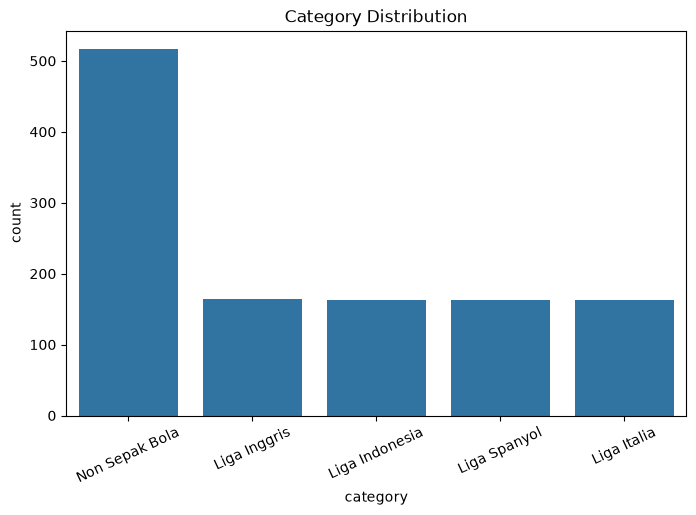

In [42]:
# ==========================================================
# LABEL DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=dataset,
    x="category",
    order=dataset["category"].value_counts().index
)

plt.xticks(rotation=25)

plt.title("Category Distribution")

plt.show()

## 6.9 Save Clean Dataset

In [43]:
# ==========================================================
# SAVE CLEAN DATASET
# ==========================================================

dataset.to_csv(
    "data/question1/dataset_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved :", len(dataset), "articles")

Saved : 1170 articles


# 7. Tokenization

Karena model yang digunakan merupakan pretrained language model, maka teks perlu diubah menjadi token menggunakan tokenizer bawaan dari model tersebut.

## 7.1 Load Tokenizer

In [44]:
# ==========================================================
# LOAD TOKENIZER
# ==========================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(tokenizer)

BertTokenizer(name_or_path='indobenchmark/indobert-base-p1', vocab_size=30521, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


## 7.2 Train Validation Test Split

In [45]:
# ==========================================================
# TRAIN VALIDATION TEST SPLIT
# ==========================================================

train_df, temp_df = train_test_split(
    dataset,
    test_size=0.20,
    stratify=dataset["label"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train :", len(train_df))
print("Valid :", len(valid_df))
print("Test  :", len(test_df))

Train : 936
Valid : 117
Test  : 117


## 7.3 Cek Distribusi

In [46]:
print(train_df["category"].value_counts())

print(valid_df["category"].value_counts())

print(test_df["category"].value_counts())

category
Non Sepak Bola    414
Liga Inggris      131
Liga Indonesia    131
Liga Italia       130
Liga Spanyol      130
Name: count, dtype: int64
category
Non Sepak Bola    52
Liga Spanyol      17
Liga Indonesia    16
Liga Italia       16
Liga Inggris      16
Name: count, dtype: int64
category
Non Sepak Bola    51
Liga Italia       17
Liga Inggris      17
Liga Spanyol      16
Liga Indonesia    16
Name: count, dtype: int64


## 7.4 Convert ke HuggingFace Dataset

In [47]:
# ==========================================================
# CONVERT TO HUGGINGFACE DATASET
# ==========================================================

train_dataset = Dataset.from_pandas(train_df)

valid_dataset = Dataset.from_pandas(valid_df)

test_dataset = Dataset.from_pandas(test_df)

## 7.5 Tokenization Function

In [48]:
# ==========================================================
# TOKENIZATION
# ==========================================================

MAX_LENGTH = 512

def tokenize(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH

    )

## 7.6 Tokenize Dataset

In [49]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/936 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

## 7.7 Remove Unused Columns

In [50]:
train_dataset = train_dataset.remove_columns(
    ["text","media","category","url","__index_level_0__"]
)

valid_dataset = valid_dataset.remove_columns(
    ["text","media","category","url","__index_level_0__"]
)

test_dataset = test_dataset.remove_columns(
    ["text","media","category","url","__index_level_0__"]
)

## 7.8 Rename Label

Trainer HuggingFace mengharapkan kolom target bernama labels.

In [51]:
train_dataset = train_dataset.rename_column("label", "labels")

valid_dataset = valid_dataset.rename_column("label", "labels")

test_dataset = test_dataset.rename_column("label", "labels")

## 7.9 Set Format

In [52]:
train_dataset.set_format("torch")

valid_dataset.set_format("torch")

test_dataset.set_format("torch")

# 8. One-Stage Fine-Tuning

Pada metode ini model langsung memprediksi lima kelas sekaligus, yaitu olahraga non sepak bola, Liga Inggris, Liga Indonesia, Liga Spanyol, dan Liga Italia.

Model yang digunakan merupakan pretrained transformer yang kemudian dilakukan fine-tuning menggunakan dataset yang telah disiapkan.

In [53]:
# ==========================================================
# LOAD INDOBERT MODEL
# ==========================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

print(model.config)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "_num_labels": 5,
  "add_cross_attention": false,
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "decoder_start_token_id": null,
  "directionality": "bidi",
  "dtype": "float32",
  "eos_token_id": null,
  "finetuning_task": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "

In [54]:
# ==========================================================
# EVALUATION METRICS
# ==========================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [55]:
# ==========================================================
# TRAINING ARGUMENTS
# ==========================================================

training_args = TrainingArguments(

    output_dir="./models",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none",

    seed=42
)

In [56]:
# ==========================================================
# TRAINER
# ==========================================================

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics

)

In [57]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.421406,0.135905,0.965812,0.968275,0.965812,0.965317
2,0.077404,0.158858,0.965812,0.968275,0.965812,0.965317
3,0.042259,0.148040,0.957265,0.958656,0.957265,0.956797


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=351, training_loss=0.18035635309681253, metrics={'train_runtime': 641.9547, 'train_samples_per_second': 4.374, 'train_steps_per_second': 0.547, 'total_flos': 738835744038912.0, 'train_loss': 0.18035635309681253, 'epoch': 3.0})

In [58]:
# ==========================================================
# SAVE MODEL
# ==========================================================

trainer.save_model("./models/question1/model_1stage")
tokenizer.save_pretrained("./models/question1/model_1stage")

print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


In [59]:
trainer.state

TrainerState(epoch=3.0, global_step=351, max_steps=351, logging_steps=500, eval_steps=500, save_steps=500, train_batch_size=8, num_train_epochs=3, num_input_tokens_seen=0, total_flos=738835744038912.0, log_history=[{'loss': 0.4214061508830796, 'grad_norm': 0.3332318067550659, 'learning_rate': 1.3390313390313392e-05, 'epoch': 1.0, 'step': 117}, {'eval_loss': 0.13590532541275024, 'eval_accuracy': 0.9658119658119658, 'eval_precision': 0.9682753655532438, 'eval_recall': 0.9658119658119658, 'eval_f1': 0.965317398650732, 'eval_runtime': 7.4513, 'eval_samples_per_second': 15.702, 'eval_steps_per_second': 2.013, 'epoch': 1.0, 'step': 117}, {'loss': 0.07740409557635967, 'grad_norm': 1.042140245437622, 'learning_rate': 6.723646723646724e-06, 'epoch': 2.0, 'step': 234}, {'eval_loss': 0.15885773301124573, 'eval_accuracy': 0.9658119658119658, 'eval_precision': 0.9682753655532438, 'eval_recall': 0.9658119658119658, 'eval_f1': 0.965317398650732, 'eval_runtime': 7.6345, 'eval_samples_per_second': 15.3

# 9. One-Stage Evaluation

Setelah proses training selesai, model dievaluasi menggunakan data testing. 

## 9.1 Load Best Model

In [60]:
# ==========================================================
# DEVICE
# ==========================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

mps


In [61]:
# ==========================================================
# LOAD TRAINED MODEL
# ==========================================================

MODEL_PATH = "./models/question1/model_1stage"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

model.to(device)

print("Model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully.


## 9.2 Predict

In [63]:
# ==========================================================
# PREDICT VALIDATION DATA
# ==========================================================

predictions = trainer.predict(valid_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

print("Prediction finished.")

Prediction finished.


## 9.3 Accuracy Precision Recall F1

Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, dan F1-Score.

In [64]:
# ==========================================================
# EVALUATION METRICS
# ==========================================================

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

MODEL PERFORMANCE
Accuracy  : 0.9658
Precision : 0.9683
Recall    : 0.9658
F1 Score  : 0.9653


## 9.4 Classification Report

Selain itu ditampilkan Classification Report dan Confusion Matrix untuk melihat performa model pada setiap kelas.

In [65]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

label_names = list(LABEL_MAPPING.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        digits=4
    )
)

                precision    recall  f1-score   support

  Liga Inggris     1.0000    0.8750    0.9333        16
Liga Indonesia     1.0000    0.8750    0.9333        16
  Liga Spanyol     0.8947    1.0000    0.9444        17
   Liga Italia     0.9412    1.0000    0.9697        16
Non Sepak Bola     0.9811    1.0000    0.9905        52

      accuracy                         0.9658       117
     macro avg     0.9634    0.9500    0.9543       117
  weighted avg     0.9683    0.9658    0.9653       117



## 9.5 Confusion Matrix

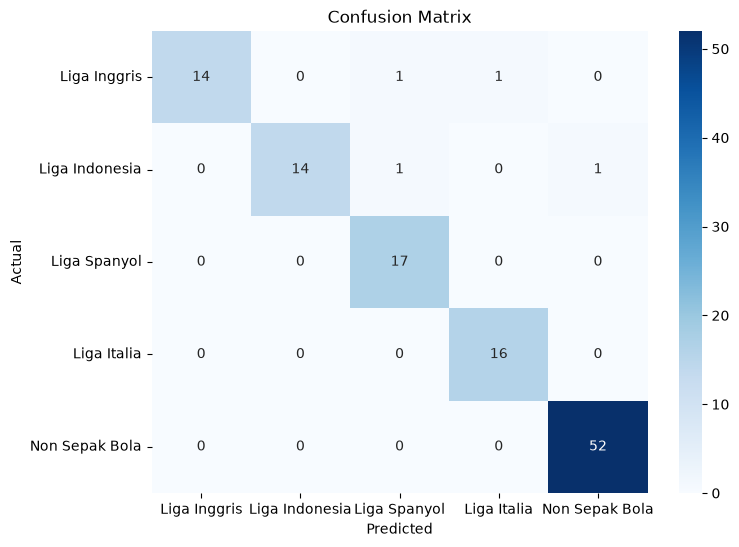

In [66]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## 9.6 Save Evaluation Result

In [67]:
# ==========================================================
# SAVE CLASSIFICATION REPORT
# ==========================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "./output/question1/results/classification_report.csv",
    index=True,
    encoding="utf-8-sig"
)

print("Classification report saved.")

Classification report saved.


# 10. Two-Stage Classification

Model two-stage menggunakan dua buah model klasifikasi.

- **Stage 1** melakukan klasifikasi biner untuk menentukan apakah artikel termasuk **Sepak Bola** atau **Non Sepak Bola**.
- **Stage 2** hanya dijalankan apabila hasil Stage 1 adalah **Sepak Bola**, kemudian mengklasifikasikan artikel ke dalam salah satu dari empat liga, yaitu Liga Inggris, Liga Indonesia, Liga Spanyol, atau Liga Italia.

## 10.1 Prepare Stage-1 Dataset

In [68]:
# ==========================================================
# STAGE 1 DATASET
# Football vs Non Football
# ==========================================================

dataset_stage1 = dataset.copy()

dataset_stage1["label"] = dataset_stage1["category"].apply(
    lambda x: 1 if x == "Non Sepak Bola" else 0
)

dataset_stage1["stage1_label"] = dataset_stage1["label"].map({
    0: "Sepak Bola",
    1: "Non Sepak Bola"
})

print("="*60)
print("STAGE 1 DATASET")
print("="*60)

print(dataset_stage1["stage1_label"].value_counts())

dataset_stage1.head()

STAGE 1 DATASET
stage1_label
Sepak Bola        653
Non Sepak Bola    517
Name: count, dtype: int64


,text,media,category,label,url,stage1_label
0,"chelsea tampak menyindir keras enzo maresca , ...",Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...,Sepak Bola
1,enzo maresca resmi menjadi penerus pep guardio...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...,Sepak Bola
2,kepergian enzo maresca membuat chelsea kalang ...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...,Sepak Bola
3,enzo maresca telah resmi menjadi manajer manch...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...,Sepak Bola
4,manchester city resmi mengumumkan enzo maresca...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...,Sepak Bola


## 10.2 Train Validation Split

In [69]:
# ==========================================================
# TRAIN VALID SPLIT
# ==========================================================

train_stage1, valid_stage1 = train_test_split(

    dataset_stage1,

    test_size=0.1,

    stratify=dataset_stage1["label"],

    random_state=42

)

print("Train :", len(train_stage1))
print("Valid :", len(valid_stage1))

Train : 1053
Valid : 117


## 10.3 HuggingFace Dataset

In [70]:
# ==========================================================
# HUGGINGFACE DATASET
# ==========================================================

train_stage1 = Dataset.from_pandas(
    train_stage1[["text","label"]]
)

valid_stage1 = Dataset.from_pandas(
    valid_stage1[["text","label"]]
)

print(train_stage1)
print(valid_stage1)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 1053
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 117
})


## 10.4 Tokenization

In [71]:
# ==========================================================
# TOKENIZATION
# ==========================================================

def tokenize_stage1(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=256

    )


train_stage1 = train_stage1.map(
    tokenize_stage1,
    batched=True
)

valid_stage1 = valid_stage1.map(
    tokenize_stage1,
    batched=True
)

train_stage1.set_format(
    "torch",
    columns=["input_ids","attention_mask","label"]
)

valid_stage1.set_format(
    "torch",
    columns=["input_ids","attention_mask","label"]
)

print("Stage 1 tokenization finished.")

Map:   0%|          | 0/1053 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

Stage 1 tokenization finished.


## 10.5 Load Model

In [72]:
# ==========================================================
# LOAD INDOBERT
# ==========================================================

model_stage1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model_stage1.to(device)

print("Stage 1 model loaded.")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Stage 1 model loaded.


## 10.6 Evaluation Metric

In [73]:
# ==========================================================
# METRIC
# ==========================================================

def compute_metrics_stage1(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 10.7 Training Arguments

In [74]:
# ==========================================================
# TRAINING ARGUMENTS
# ==========================================================

training_args_stage1 = TrainingArguments(

    output_dir="./models/question1/model_2stage/stage1",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none",

    seed=42
)

## 10.8 Trainer

In [75]:
# ==========================================================
# TRAINER
# ==========================================================

trainer_stage1 = Trainer(

    model=model_stage1,

    args=training_args_stage1,

    train_dataset=train_stage1,

    eval_dataset=valid_stage1,

    processing_class=tokenizer,

    compute_metrics=compute_metrics_stage1
)

## 10.9 Train

In [76]:
# ==========================================================
# TRAIN
# ==========================================================

trainer_stage1.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.108877,0.019467,0.991453,0.991614,0.991453,0.991461
2,0.009351,0.000158,1.000000,1.000000,1.000000,1.000000
3,0.000171,0.000125,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=396, training_loss=0.03946626474234191, metrics={'train_runtime': 350.6552, 'train_samples_per_second': 9.009, 'train_steps_per_second': 1.129, 'total_flos': 415583911941120.0, 'train_loss': 0.03946626474234191, 'epoch': 3.0})

In [77]:
# ==========================================================
# SAVE STAGE 1 MODEL
# ==========================================================

trainer_stage1.save_model("./models/question1/model_2stage/stage1")

tokenizer.save_pretrained("./models/question1/model_2stage/stage1")

print("Stage 1 model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 1 model saved.


In [78]:
# ==========================================================
# STAGE 1 PREDICTION
# ==========================================================

predictions_stage1 = trainer_stage1.predict(valid_stage1)

y_pred_stage1 = np.argmax(predictions_stage1.predictions, axis=1)

y_true_stage1 = predictions_stage1.label_ids

print("Prediction finished.")

Prediction finished.


In [79]:
# ==========================================================
# STAGE 1 METRICS
# ==========================================================

accuracy = accuracy_score(y_true_stage1, y_pred_stage1)

precision, recall, f1, _ = precision_recall_fscore_support(

    y_true_stage1,

    y_pred_stage1,

    average="weighted"

)

print("="*60)
print("STAGE 1 PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

STAGE 1 PERFORMANCE
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


In [80]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

stage1_names = [

    "Sepak Bola",

    "Non Sepak Bola"

]

print(

    classification_report(

        y_true_stage1,

        y_pred_stage1,

        target_names=stage1_names,

        digits=4

    )

)

                precision    recall  f1-score   support

    Sepak Bola     1.0000    1.0000    1.0000        65
Non Sepak Bola     1.0000    1.0000    1.0000        52

      accuracy                         1.0000       117
     macro avg     1.0000    1.0000    1.0000       117
  weighted avg     1.0000    1.0000    1.0000       117



# 11. Two-Stage Classification — Stage 2

Stage 2 bertujuan mengklasifikasikan artikel yang telah diprediksi sebagai **Sepak Bola** menjadi salah satu dari empat liga, yaitu:

- Liga Inggris
- Liga Indonesia
- Liga Spanyol
- Liga Italia

## 11.1 Prepare Dataset

In [81]:
# ==========================================================
# STAGE 2 DATASET
# ==========================================================

dataset_stage2 = dataset.copy()

# Ambil hanya artikel sepak bola
dataset_stage2 = dataset_stage2[
    dataset_stage2["category"] != "Non Sepak Bola"
].copy()

# Mapping label
stage2_mapping = {
    "Liga Inggris": 0,
    "Liga Indonesia": 1,
    "Liga Spanyol": 2,
    "Liga Italia": 3
}

dataset_stage2["label"] = dataset_stage2["category"].map(stage2_mapping)

print("="*60)
print("STAGE 2 DATASET")
print("="*60)

print(dataset_stage2["category"].value_counts())

print()

print("Total :", len(dataset_stage2))

dataset_stage2.head()

STAGE 2 DATASET
category
Liga Inggris      164
Liga Indonesia    163
Liga Spanyol      163
Liga Italia       163
Name: count, dtype: int64

Total : 653


,text,media,category,label,url
0,"chelsea tampak menyindir keras enzo maresca , ...",Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
1,enzo maresca resmi menjadi penerus pep guardio...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
2,kepergian enzo maresca membuat chelsea kalang ...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
3,enzo maresca telah resmi menjadi manajer manch...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...
4,manchester city resmi mengumumkan enzo maresca...,Detik,Liga Inggris,0,https://sport.detik.com/sepakbola/liga-inggris...


## 11.2 Train Validation Split

In [82]:
# ==========================================================
# TRAIN VALID SPLIT
# ==========================================================

train_stage2, valid_stage2 = train_test_split(

    dataset_stage2,

    test_size=0.1,

    stratify=dataset_stage2["label"],

    random_state=42

)

print("Train :", len(train_stage2))
print("Valid :", len(valid_stage2))

Train : 587
Valid : 66


## 11.3 HuggingFace Dataset

In [83]:
# ==========================================================
# HUGGINGFACE DATASET
# ==========================================================

train_stage2 = Dataset.from_pandas(
    train_stage2[["text","label"]]
)

valid_stage2 = Dataset.from_pandas(
    valid_stage2[["text","label"]]
)

print(train_stage2)
print(valid_stage2)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 587
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 66
})


## 11.4 Tokenization

In [84]:
# ==========================================================
# TOKENIZATION
# ==========================================================

def tokenize_stage2(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=256

    )


train_stage2 = train_stage2.map(
    tokenize_stage2,
    batched=True
)

valid_stage2 = valid_stage2.map(
    tokenize_stage2,
    batched=True
)

train_stage2.set_format(
    "torch",
    columns=["input_ids","attention_mask","label"]
)

valid_stage2.set_format(
    "torch",
    columns=["input_ids","attention_mask","label"]
)

print("Stage 2 tokenization finished.")

Map:   0%|          | 0/587 [00:00<?, ? examples/s]

Map:   0%|          | 0/66 [00:00<?, ? examples/s]

Stage 2 tokenization finished.


## 11.5 Load Model

In [85]:
# ==========================================================
# LOAD INDOBERT
# ==========================================================

model_stage2 = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=4

)

model_stage2.to(device)

print("Stage 2 model loaded.")

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Stage 2 model loaded.


## 11.6 Metrics

In [86]:
# ==========================================================
# METRICS
# ==========================================================

def compute_metrics_stage2(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        predictions,

        average="weighted"

    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

## 11.7 Training Arguments

In [87]:
# ==========================================================
# TRAINING ARGUMENTS
# ==========================================================

training_args_stage2 = TrainingArguments(

    output_dir="./models/question1/model_2stage/stage2",

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none",

    seed=42

)

## 11.8 Trainer

In [88]:
# ==========================================================
# TRAINER
# ==========================================================

trainer_stage2 = Trainer(

    model=model_stage2,

    args=training_args_stage2,

    train_dataset=train_stage2,

    eval_dataset=valid_stage2,

    processing_class=tokenizer,

    compute_metrics=compute_metrics_stage2

)

## 11.9 Train

In [89]:
# ==========================================================
# TRAIN
# ==========================================================

trainer_stage2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.506276,0.151799,0.939394,0.944551,0.939394,0.939218
2,0.154079,0.140274,0.954545,0.954545,0.954545,0.954545
3,0.078100,0.107492,0.969697,0.970588,0.969697,0.969697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=222, training_loss=0.24615196279577306, metrics={'train_runtime': 206.6184, 'train_samples_per_second': 8.523, 'train_steps_per_second': 1.074, 'total_flos': 231673444374528.0, 'train_loss': 0.24615196279577306, 'epoch': 3.0})

## 11.10 Save Model

In [90]:
# ==========================================================
# SAVE STAGE 2 MODEL
# ==========================================================

trainer_stage2.save_model(
    "./models/question1/model_2stage/stage2"
)

tokenizer.save_pretrained(
    "./models/question1/model_2stage/stage2"
)

print("Stage 2 model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 2 model saved.


## 11.11 Prediction

In [91]:
# ==========================================================
# STAGE 2 PREDICTION
# ==========================================================

predictions_stage2 = trainer_stage2.predict(valid_stage2)

y_pred_stage2 = np.argmax(
    predictions_stage2.predictions,
    axis=1
)

y_true_stage2 = predictions_stage2.label_ids

print("Prediction finished.")

Prediction finished.


## 11.12 Performance

In [92]:
# ==========================================================
# PERFORMANCE
# ==========================================================

accuracy = accuracy_score(
    y_true_stage2,
    y_pred_stage2
)

precision, recall, f1, _ = precision_recall_fscore_support(

    y_true_stage2,

    y_pred_stage2,

    average="weighted"

)

print("="*60)
print("STAGE 2 PERFORMANCE")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

STAGE 2 PERFORMANCE
Accuracy  : 0.9697
Precision : 0.9706
Recall    : 0.9697
F1 Score  : 0.9697


## 11.13 Classification Report

In [93]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

stage2_names = [

    "Liga Inggris",

    "Liga Indonesia",

    "Liga Spanyol",

    "Liga Italia"

]

print(

    classification_report(

        y_true_stage2,

        y_pred_stage2,

        target_names=stage2_names,

        digits=4

    )

)

                precision    recall  f1-score   support

  Liga Inggris     1.0000    0.9412    0.9697        17
Liga Indonesia     1.0000    1.0000    1.0000        16
  Liga Spanyol     0.9412    1.0000    0.9697        16
   Liga Italia     0.9412    0.9412    0.9412        17

      accuracy                         0.9697        66
     macro avg     0.9706    0.9706    0.9701        66
  weighted avg     0.9706    0.9697    0.9697        66



## 11.14 Confusion Matrix

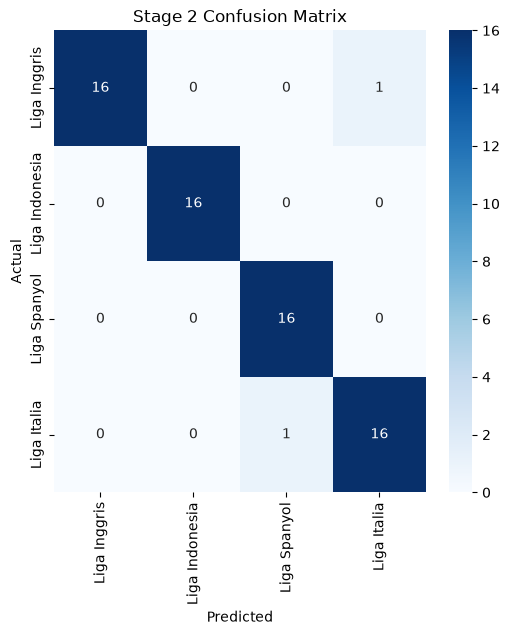

In [94]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_true_stage2,
    y_pred_stage2
)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=stage2_names,

    yticklabels=stage2_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Stage 2 Confusion Matrix")

plt.show()

## 11.15 Save Report

In [95]:
# ==========================================================
# SAVE REPORT
# ==========================================================

report = classification_report(

    y_true_stage2,

    y_pred_stage2,

    target_names=stage2_names,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(

    "./output/question1/results/stage2_classification_report.csv",

    encoding="utf-8-sig"

)

print("Stage 2 report saved.")

Stage 2 report saved.


# 12. Two-Stage Inference Pipeline

Bagian ini mengimplementasikan arsitektur Two-Stage Classification menggunakan dua model yang telah dilatih sebelumnya.

Alur prediksi:

Input Artikel

↓

Stage 1
- Sepak Bola
- Non Sepak Bola

↓

Jika Sepak Bola

↓

Stage 2
- Liga Inggris
- Liga Indonesia
- Liga Spanyol
- Liga Italia

↓

Final Prediction

In [96]:
# ==========================================================
# LOAD SAVED MODELS
# ==========================================================

MODEL_STAGE1 = "./models/question1/model_2stage/stage1"

MODEL_STAGE2 = "./models/question1/model_2stage/stage2"

tokenizer_stage1 = AutoTokenizer.from_pretrained(MODEL_STAGE1)

model_stage1 = AutoModelForSequenceClassification.from_pretrained(MODEL_STAGE1)

model_stage1.to(device)

model_stage1.eval()


tokenizer_stage2 = AutoTokenizer.from_pretrained(MODEL_STAGE2)

model_stage2 = AutoModelForSequenceClassification.from_pretrained(MODEL_STAGE2)

model_stage2.to(device)

model_stage2.eval()

print("Two-stage models loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Two-stage models loaded successfully.


In [97]:
# ==========================================================
# LABEL MAPPING
# ==========================================================

stage1_labels = {

    0: "Sepak Bola",

    1: "Non Sepak Bola"

}

stage2_labels = {

    0: "Liga Inggris",

    1: "Liga Indonesia",

    2: "Liga Spanyol",

    3: "Liga Italia"

}

In [98]:
# ==========================================================
# STAGE 1 PREDICTION
# ==========================================================

import torch.nn.functional as F

def predict_stage1(text):

    inputs = tokenizer_stage1(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model_stage1(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    confidence, prediction = torch.max(probs, dim=1)

    return prediction.item(), confidence.item()

In [99]:
# ==========================================================
# STAGE 2 PREDICTION
# ==========================================================

def predict_stage2(text):

    inputs = tokenizer_stage2(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model_stage2(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    confidence, prediction = torch.max(probs, dim=1)

    return prediction.item(), confidence.item()

In [100]:
# ==========================================================
# TWO-STAGE PIPELINE
# ==========================================================

def predict_article(text):

    print("="*70)
    print("          TWO-STAGE CLASSIFICATION RESULT")
    print("="*70)

    print("\nARTICLE PREVIEW")
    print("-"*70)
    print(text[:300] + "..." if len(text) > 300 else text)

    # -------------------------
    # Stage 1
    # -------------------------
    stage1_pred, stage1_conf = predict_stage1(text)

    print("\n" + "="*70)
    print("STAGE 1")
    print("="*70)

    print(f"Prediction : {stage1_labels[stage1_pred]}")
    print(f"Confidence : {stage1_conf*100:.2f}%")

    # -------------------------
    # Non Football
    # -------------------------
    if stage1_pred == 1:

        print("\n" + "="*70)
        print("STAGE 2")
        print("="*70)

        print("Skipped (Article classified as Non Sepak Bola)")

        print("\n" + "="*70)
        print("FINAL PREDICTION")
        print("="*70)

        print(stage1_labels[stage1_pred])

        return stage1_labels[stage1_pred]

    # -------------------------
    # Stage 2
    # -------------------------
    stage2_pred, stage2_conf = predict_stage2(text)

    print("\n" + "="*70)
    print("STAGE 2")
    print("="*70)

    print(f"Prediction : {stage2_labels[stage2_pred]}")
    print(f"Confidence : {stage2_conf*100:.2f}%")

    print("\n" + "="*70)
    print("FINAL PREDICTION")
    print("="*70)

    print(stage2_labels[stage2_pred])

    return stage2_labels[stage2_pred]

In [101]:
# ==========================================================
# TEST FOOTBALL ARTICLE
# ==========================================================

sample = dataset[dataset["category"]=="Liga Inggris"].sample(
    1,
    random_state=42
).iloc[0]

predict_article(sample["text"])

          TWO-STAGE CLASSIFICATION RESULT

ARTICLE PREVIEW
----------------------------------------------------------------------
juara premier league , arsenal dilaporkan mulai bermanuver di bursa transfer musim panas ini. the gunners dilaporkan baru-baru ini mengajukan tawaran untuk pemain newcastle , bruno guimaraes . arsenal menutup musim 2025/2026 dengan catatan yang manis. tim besutan mikel arteta itu berhasil mengakhiri...

STAGE 1
Prediction : Sepak Bola
Confidence : 99.99%

STAGE 2
Prediction : Liga Inggris
Confidence : 99.66%

FINAL PREDICTION
Liga Inggris


'Liga Inggris'

In [102]:
# ==========================================================
# TEST NON FOOTBALL ARTICLE
# ==========================================================

sample = dataset[
    dataset["category"]=="Non Sepak Bola"
].sample(
    1,
    random_state=42
).iloc[0]

predict_article(sample["text"])

          TWO-STAGE CLASSIFICATION RESULT

ARTICLE PREVIEW
----------------------------------------------------------------------
jadwal lengkap turnamen badminton bwf 2026. para pebulu tangkis terbaik dunia kembali bertarung di singapore open 2026 pada 26-31 mei 2026 demi memperebutkan gelar juara bulu tangkis bergengsi singapore open 2026 merupakan turnamen bwf level super 750, yang digelar di singapore indoor stadium. indon...

STAGE 1
Prediction : Non Sepak Bola
Confidence : 99.98%

STAGE 2
Skipped (Article classified as Non Sepak Bola)

FINAL PREDICTION
Non Sepak Bola


'Non Sepak Bola'

# 12. Conclusion

Two-Stage Classification diimplementasikan menggunakan dua model IndoBERT secara berurutan. Stage 1 membedakan artikel Sepak Bola dan Non Sepak Bola, sedangkan Stage 2 mengklasifikasikan artikel Sepak Bola ke dalam empat kategori liga.

Hasil evaluasi One-Stage dan Two-Stage kemudian dibandingkan menggunakan Accuracy, Precision, Recall, dan F1-Score.


# 13. Model Comparison

Bagian ini membandingkan performa model One-Stage Classification dan Two-Stage Classification berdasarkan metrik Accuracy, Precision, Recall, dan F1-Score pada data training, validation, dan testing.

In [103]:
# ==========================================================
# TRAINING METRICS - ONE STAGE
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

pred = trainer.predict(train_dataset)

y_true_train = pred.label_ids
y_pred_train = pred.predictions.argmax(axis=1)

train_accuracy = accuracy_score(y_true_train, y_pred_train)

train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
    y_true_train,
    y_pred_train,
    average="weighted"
)

print("="*60)
print("ONE STAGE - TRAINING")
print("="*60)

print(f"Accuracy  : {train_accuracy:.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall:.4f}")
print(f"F1 Score  : {train_f1:.4f}")

ONE STAGE - TRAINING
Accuracy  : 0.9690
Precision : 0.9710
Recall    : 0.9690
F1 Score  : 0.9690


In [104]:
# ==========================================================
# TWO-STAGE PREDICTION (NO PRINT)
# ==========================================================

def predict_pipeline(text):

    stage1_pred, _ = predict_stage1(text)

    # Non Sepak Bola
    if stage1_pred == 1:
        return 4

    # Football
    stage2_pred, _ = predict_stage2(text)

    return stage2_pred


In [105]:
# ==========================================================
# PREDICT TEST SET
# ==========================================================

y_true = []
y_pred = []

for _, row in test_df.iterrows():

    y_true.append(row["label"])

    pred = predict_pipeline(row["text"])

    y_pred.append(pred)

print(f"Total test articles : {len(y_true)}")

Total test articles : 117


In [106]:
# ==========================================================
# TWO-STAGE PIPELINE EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

pipeline_accuracy = accuracy_score(y_true, y_pred)

pipeline_precision, pipeline_recall, pipeline_f1, _ = \
precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

print("="*60)
print("TWO-STAGE PIPELINE")
print("="*60)

print(f"Accuracy  : {pipeline_accuracy:.4f}")
print(f"Precision : {pipeline_precision:.4f}")
print(f"Recall    : {pipeline_recall:.4f}")
print(f"F1 Score  : {pipeline_f1:.4f}")

TWO-STAGE PIPELINE
Accuracy  : 0.9744
Precision : 0.9763
Recall    : 0.9744
F1 Score  : 0.9743


In [107]:
label_names = [

    "Liga Inggris",

    "Liga Indonesia",

    "Liga Spanyol",

    "Liga Italia",

    "Non Sepak Bola"

]

print(

    classification_report(

        y_true,

        y_pred,

        target_names=label_names

    )

)

                precision    recall  f1-score   support

  Liga Inggris       1.00      0.88      0.94        17
Liga Indonesia       1.00      1.00      1.00        16
  Liga Spanyol       0.89      1.00      0.94        16
   Liga Italia       0.94      0.94      0.94        17
Non Sepak Bola       1.00      1.00      1.00        51

      accuracy                           0.97       117
     macro avg       0.97      0.96      0.96       117
  weighted avg       0.98      0.97      0.97       117



In [108]:
# ==========================================================
# MODEL COMPARISON
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "One-Stage":[
        accuracy,
        precision,
        recall,
        f1
    ],

    "Two-Stage":[
        pipeline_accuracy,
        pipeline_precision,
        pipeline_recall,
        pipeline_f1
    ]

})

comparison = comparison.round(4)

comparison

,Metric,One-Stage,Two-Stage
0,Accuracy,0.9697,0.9744
1,Precision,0.9706,0.9763
2,Recall,0.9697,0.9744
3,F1 Score,0.9697,0.9743


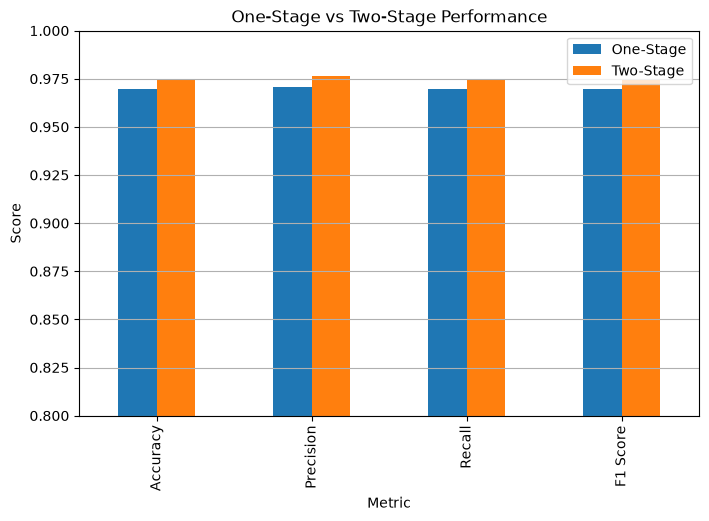

In [109]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("One-Stage vs Two-Stage Performance")
plt.ylabel("Score")
plt.ylim(0.8,1.0)

plt.grid(axis="y")

plt.show()

## Comparison Result

Hasil evaluasi menunjukkan bahwa pendekatan Two-Stage memperoleh nilai metrik yang lebih tinggi dibandingkan One-Stage pada evaluasi yang dilakukan. Pendekatan bertahap memecah tugas klasifikasi menjadi dua tahap sehingga setiap model menangani jumlah kelas yang lebih sedikit.
